In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K


# --------------------------------------------------------
# 1️⃣ Define Custom L2 Normalization Layer
# --------------------------------------------------------
class L2Normalization(Layer):
    def __init__(self, axis=-1, **kwargs):
        super(L2Normalization, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=self.axis)

    def get_config(self):
        config = super().get_config()
        config.update({"axis": self.axis})
        return config


# OPTIONAL: If your models include projection head or stop-gradient functions
# you can define placeholders (they are often identity layers in SSL)

class IdentityLayer(Layer):
    def call(self, x):
        return x


custom_objects = {
    "L2Normalization": L2Normalization,
    "IdentityLayer": IdentityLayer,
}

2025-12-14 08:07:38.109759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765699658.469207      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765699658.573597      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import os

base_dir = "/kaggle/input/alzeihmer-disease-model/other/default/1"

simclr_path = os.path.join(base_dir, "alzheimer_ssl_2 SimCLRmodel.h5")
simsam_path = os.path.join(base_dir, "alzheimer_ssl_3 -Simsiammodel.h5")
barlow_path = os.path.join(base_dir, "alzheimer_ssl_4- Barlow twinsmodel.h5")

print("Loading SSL Models with custom layers...")

simclr_model = tf.keras.models.load_model(simclr_path, custom_objects=custom_objects)
simsam_model = tf.keras.models.load_model(simsam_path, custom_objects=custom_objects)
barlow_model = tf.keras.models.load_model(barlow_path, custom_objects=custom_objects)

print("✅ All SSL models loaded successfully!")

Loading SSL Models with custom layers...


I0000 00:00:1765699681.974949      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ All SSL models loaded successfully!


In [3]:
#Setup + paths (auto-detect train/test folders)
import os, glob, json, math, random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("TF:", tf.__version__)


TF: 2.18.0


In [4]:
# ========= USER PATHS =========
SSL_BASE_DIR = "/kaggle/input/alzeihmer-disease-model/other/default/1"
DATASET_ROOT = "/kaggle/input/alzheimer-disease"

simclr_path  = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_2 SimCLRmodel.h5")
simsam_path  = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_3 -Simsiammodel.h5")
barlow_path  = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_4- Barlow twinsmodel.h5")

print("SSL model paths:")
print(simclr_path)
print(simsam_path)
print(barlow_path)

# ========= AUTO-FIND train/test directories =========
CLASSES = ["AD", "CN", "MCI"]  # keep your order consistent everywhere

def find_split_dir(root, split_name="train"):
    """
    Finds a directory that contains subfolder `split_name` and inside it the class folders.
    Works for structures like:
      /kaggle/input/alzheimer-disease/train-.../train/AD ...
      /kaggle/input/alzheimer-disease/test-.../test/AD ...
    """
    candidates = []
    for dirpath, dirnames, filenames in os.walk(root):
        base = os.path.basename(dirpath).lower()
        if base == split_name.lower():
            # check classes exist
            ok = all(os.path.isdir(os.path.join(dirpath, c)) for c in CLASSES)
            if ok:
                candidates.append(dirpath)
    # pick shortest (closest to root) if multiple
    candidates = sorted(candidates, key=lambda p: len(p))
    return candidates[0] if candidates else None

train_dir = find_split_dir(DATASET_ROOT, "train")
test_dir  = find_split_dir(DATASET_ROOT, "test")

print("Resolved train_dir:", train_dir)
print("Resolved test_dir :", test_dir)

assert train_dir is not None, "Could not find a valid train/ directory containing AD,CN,MCI."
assert test_dir  is not None, "Could not find a valid test/ directory containing AD,CN,MCI."


SSL model paths:
/kaggle/input/alzeihmer-disease-model/other/default/1/alzheimer_ssl_2 SimCLRmodel.h5
/kaggle/input/alzeihmer-disease-model/other/default/1/alzheimer_ssl_3 -Simsiammodel.h5
/kaggle/input/alzeihmer-disease-model/other/default/1/alzheimer_ssl_4- Barlow twinsmodel.h5
Resolved train_dir: /kaggle/input/alzheimer-disease/train-20251010T183510Z-1-001/train
Resolved test_dir : /kaggle/input/alzheimer-disease/test-20251010T094612Z-1-001/test


In [5]:
#Data loaders (train/val/test) – stable & reproducible
IMG_SIZE = (224, 224)  
BATCH_SIZE = 32

def make_ds(directory, shuffle=True):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="int",
        class_names=CLASSES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED
    )
    return ds

train_full = make_ds(train_dir, shuffle=True)
test_ds    = make_ds(test_dir, shuffle=False)

# split train -> train/val
VAL_FRAC = 0.2
card = tf.data.experimental.cardinality(train_full).numpy()
val_batches = max(1, int(card * VAL_FRAC))
train_batches = card - val_batches

val_ds   = train_full.take(val_batches)
train_ds = train_full.skip(val_batches)

print("Batches - train:", tf.data.experimental.cardinality(train_ds).numpy(),
      "val:", tf.data.experimental.cardinality(val_ds).numpy(),
      "test:", tf.data.experimental.cardinality(test_ds).numpy())

# normalization (0..1)
norm = layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x,y: (norm(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x,y: (norm(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x,y: (norm(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


Found 4123 files belonging to 3 classes.
Found 1031 files belonging to 3 classes.
Batches - train: 104 val: 25 test: 33


In [6]:
#Defining the L2 Normalization
import tensorflow as tf
from tensorflow import keras

@keras.utils.register_keras_serializable(package="Custom")
class L2Normalization(keras.layers.Layer):
    def __init__(self, axis=-1, epsilon=1e-12, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis
        self.epsilon = epsilon

    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=self.axis, epsilon=self.epsilon)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"axis": self.axis, "epsilon": self.epsilon})
        return cfg


In [7]:
#Loading Models 
import os
import tensorflow as tf

SSL_BASE_DIR = "/kaggle/input/alzeihmer-disease-model/other/default/1"

simclr_path = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_2 SimCLRmodel.h5")
simsam_path = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_3 -Simsiammodel.h5")
barlow_path = os.path.join(SSL_BASE_DIR, "alzheimer_ssl_4- Barlow twinsmodel.h5")

custom_objects = {
    "L2Normalization": L2Normalization,
}

print("Loading SSL Models with custom_object_scope...")

with keras.utils.custom_object_scope(custom_objects):
    simclr_model = tf.keras.models.load_model(simclr_path, compile=False)
    simsam_model = tf.keras.models.load_model(simsam_path, compile=False)
    barlow_model = tf.keras.models.load_model(barlow_path, compile=False)

print(" All SSL models loaded successfully!")


Loading SSL Models with custom_object_scope...
 All SSL models loaded successfully!


In [8]:
#Build Encoders from SSL Models
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def make_encoder(ssl_model):
    """
    Robustly extracts an encoder from an SSL model.
    Priority:
    1. Known encoder/backbone layer names
    2. Second last layer (typical SSL practice)
    """
    preferred_names = [
        "encoder", "backbone", "base_encoder",
        "feature_extractor", "resnet", "convnext"
    ]

    for name in preferred_names:
        try:
            layer = ssl_model.get_layer(name)
            print(f"Using encoder layer: {name}")
            return keras.Model(
                inputs=ssl_model.input,
                outputs=layer.output,
                name=f"{ssl_model.name}_{name}"
            )
        except:
            pass

    # Fallback → second last layer
    print(" Encoder not explicitly found → using fallback (2nd last layer)")
    output = ssl_model.layers[-2].output
    return keras.Model(
        inputs=ssl_model.input,
        outputs=output,
        name=f"{ssl_model.name}_encoder_fallback"
    )


enc_simclr  = make_encoder(simclr_model)
enc_simsam  = make_encoder(simsam_model)
enc_barlow  = make_encoder(barlow_model)

print("Encoder outputs:")
print("SimCLR :", enc_simclr.output_shape)
print("SimSiam:", enc_simsam.output_shape)
print("Barlow :", enc_barlow.output_shape)


 Encoder not explicitly found → using fallback (2nd last layer)
 Encoder not explicitly found → using fallback (2nd last layer)
 Encoder not explicitly found → using fallback (2nd last layer)
Encoder outputs:
SimCLR : (None, 256)
SimSiam: (None, 256)
Barlow : (None, 256)


In [9]:
#Dataset Pipeline (Train / Val / Test)
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

CLASSES = ["AD", "CN", "MCI"]

train_ds_full = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=CLASSES,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=CLASSES,
    label_mode="int",
    shuffle=False
)

# Train/Val split
val_fraction = 0.2
total_batches = tf.data.experimental.cardinality(train_ds_full).numpy()
val_batches = int(total_batches * val_fraction)

val_ds   = train_ds_full.take(val_batches)
train_ds = train_ds_full.skip(val_batches)

# Normalization
normalizer = layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x,y: (normalizer(x), y)).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x,y: (normalizer(x), y)).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x,y: (normalizer(x), y)).prefetch(AUTOTUNE)

print("Dataset ready ")


Found 4123 files belonging to 3 classes.
Found 1031 files belonging to 3 classes.
Dataset ready 


In [10]:
#LARS Optimizer (Safe Fallback)
def get_optimizer(name="lars", lr=1e-3):
    name = name.lower()
    if name == "lars":
        try:
            import tensorflow_addons as tfa
            print("Using LARS optimizer")
            return tfa.optimizers.LARS(learning_rate=lr, momentum=0.9)
        except:
            print(" LARS unavailable → falling back to Adam")
            return keras.optimizers.Adam(learning_rate=lr)
    elif name == "sgd":
        return keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        return keras.optimizers.Adam(learning_rate=lr)


In [11]:
#Downstream Classifier Head
NUM_CLASSES = len(CLASSES)

def build_downstream_model(encoder, trainable=False, dropout=0.3):
    encoder.trainable = trainable

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = encoder(inputs)

    # Handle spatial / vector outputs
    if len(x.shape) == 4:
        x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=f"downstream_{encoder.name}")
    return model


In [12]:
#Train Downstream Models (SimCLR / SimSiam / Barlow)
EPOCHS = 30
LR = 1e-3
OPT = "lars"

models = {}
histories = {}

for name, encoder in {
    "SimCLR": enc_simclr,
    "SimSiam": enc_simsam,
    "BarlowTwins": enc_barlow
}.items():

    print(f"\n==== Training downstream: {name} ====")

    model = build_downstream_model(encoder, trainable=False)

    model.compile(
        optimizer=get_optimizer(OPT, LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=2)
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    models[name] = model
    histories[name] = history



==== Training downstream: SimCLR ====
 LARS unavailable → falling back to Adam
Epoch 1/30


I0000 00:00:1765699740.415592      59 service.cc:148] XLA service 0x7c72d8003320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765699740.416913      59 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765699745.360101      59 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/104 ━━━━━━━━━━━━━━━━━━━━ 1:43:03 60s/step - accuracy: 0.3438 - loss: 1.1692

I0000 00:00:1765699767.991189      59 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


104/104 ━━━━━━━━━━━━━━━━━━━━ 105s 436ms/step - accuracy: 0.4372 - loss: 1.1776 - val_accuracy: 0.2763 - val_loss: 1.1282 - learning_rate: 0.0010
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.4877 - loss: 1.0361 - val_accuracy: 0.3125 - val_loss: 1.1016 - learning_rate: 0.0010
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.5209 - loss: 1.0111 - val_accuracy: 0.4175 - val_loss: 1.1012 - learning_rate: 0.0010
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.5599 - loss: 0.9654 - val_accuracy: 0.5175 - val_loss: 1.0156 - learning_rate: 0.0010
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.5397 - loss: 0.9745 - val_accuracy: 0.2850 - val_loss: 1.1040 - learning_rate: 0.0010
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.5684 - loss: 0.9258 - val_accuracy: 0.4712 - val_loss: 1.1097 - learning_rate: 0.0010
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.5868 - loss


SimCLR Accuracy: 0.9738
              precision    recall  f1-score   support

          AD       0.99      0.91      0.95       225
          CN       0.99      0.98      0.99       288
         MCI       0.96      1.00      0.98       518

    accuracy                           0.97      1031
   macro avg       0.98      0.96      0.97      1031
weighted avg       0.97      0.97      0.97      1031



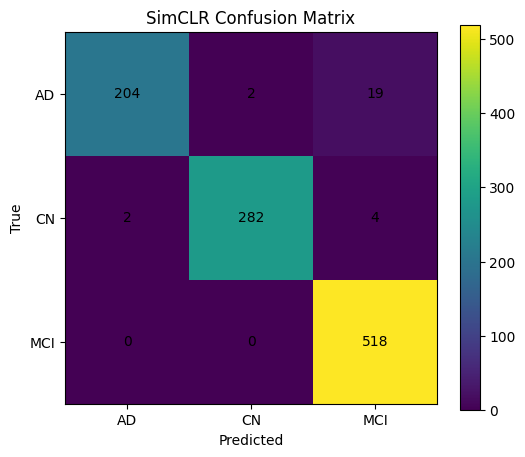


SimSiam Accuracy: 0.9767
              precision    recall  f1-score   support

          AD       1.00      0.93      0.97       225
          CN       0.93      0.99      0.96       288
         MCI       0.99      0.99      0.99       518

    accuracy                           0.98      1031
   macro avg       0.98      0.97      0.97      1031
weighted avg       0.98      0.98      0.98      1031



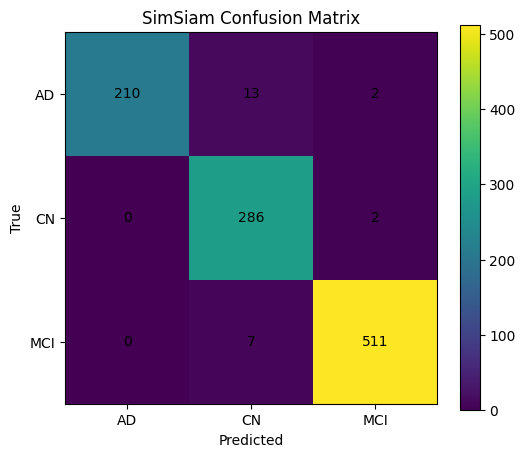


BarlowTwins Accuracy: 0.9952
              precision    recall  f1-score   support

          AD       1.00      0.98      0.99       225
          CN       0.99      1.00      0.99       288
         MCI       1.00      1.00      1.00       518

    accuracy                           1.00      1031
   macro avg       0.99      0.99      0.99      1031
weighted avg       1.00      1.00      1.00      1031



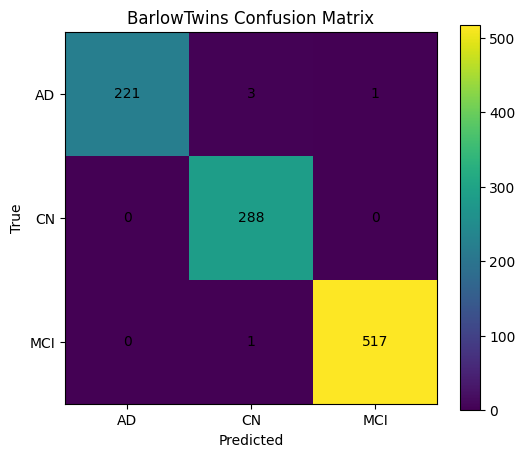

In [13]:
#Evaluation + Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

results = {}

def evaluate(model, ds, name):
    y_true, y_pred = [], []

    for x, y in ds:
        p = model.predict(x, verbose=0)
        y_true.append(y.numpy())
        y_pred.append(np.argmax(p, axis=1))

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    acc = accuracy_score(y_true, y_pred)

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title(f"{name} Confusion Matrix")
    plt.colorbar()
    plt.xticks(range(3), CLASSES)
    plt.yticks(range(3), CLASSES)

    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i,j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return acc

for name, model in models.items():
    results[name] = evaluate(model, test_ds, name)


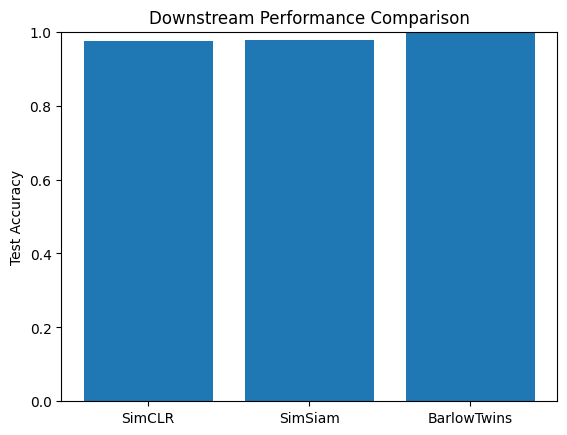

In [14]:
#Downstream Comparison Graph
plt.figure()
plt.bar(results.keys(), results.values())
plt.ylabel("Test Accuracy")
plt.title("Downstream Performance Comparison")
plt.ylim(0, 1)
plt.show()


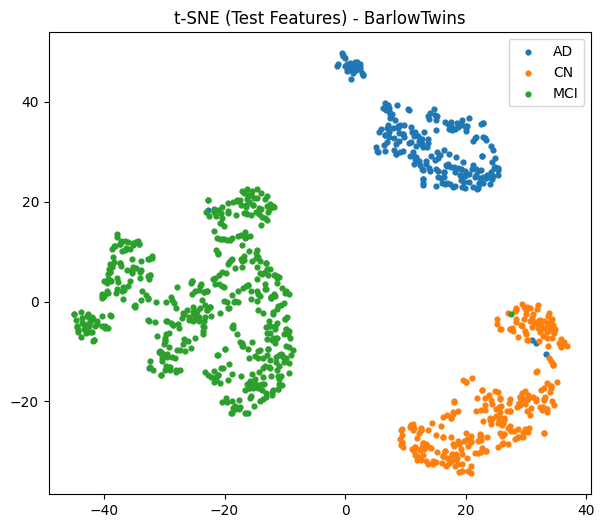

In [15]:
#t-SNE on Test Embeddings
from sklearn.manifold import TSNE

best_model_name = max(results, key=results.get)
best_encoder = {
    "SimCLR": enc_simclr,
    "SimSiam": enc_simsam,
    "BarlowTwins": enc_barlow
}[best_model_name]

features, labels = [], []

for x, y in test_ds.take(50):  # limit for speed
    f = best_encoder(x, training=False)
    if len(f.shape) == 4:
        f = tf.reduce_mean(f, axis=[1,2])
    features.append(f.numpy())
    labels.append(y.numpy())

X = np.concatenate(features)
y = np.concatenate(labels)

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
Z = tsne.fit_transform(X)

plt.figure(figsize=(7,6))
for i, cls in enumerate(CLASSES):
    idx = y == i
    plt.scatter(Z[idx,0], Z[idx,1], label=cls, s=12)

plt.title(f"t-SNE (Test Features) - {best_model_name}")
plt.legend()
plt.show()


In [16]:
#Ablation Study (Frozen vs Fine-tuned Encoder)
def unfreeze_last_layers(model, n=20):
    model.trainable = True
    for layer in model.layers[:-n]:
        layer.trainable = False

unfreeze_last_layers(best_encoder, n=20)

ft_model = build_downstream_model(best_encoder, trainable=True)
ft_model.compile(
    optimizer=get_optimizer("lars", 1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ft_history = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

plot_history(ft_history, f"{best_model_name} Fine-tuned")


 LARS unavailable → falling back to Adam
Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 92s 383ms/step - accuracy: 0.7860 - loss: 0.5153 - val_accuracy: 0.9688 - val_loss: 0.1028
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.9691 - loss: 0.1217 - val_accuracy: 0.9912 - val_loss: 0.0424
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.9815 - loss: 0.0789 - val_accuracy: 0.9862 - val_loss: 0.0519
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.9794 - loss: 0.0645 - val_accuracy: 0.9912 - val_loss: 0.0430
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.9916 - loss: 0.0309 - val_accuracy: 0.9825 - val_loss: 0.0639


NameError: name 'plot_history' is not defined